### Connect FST parser and CG3 parser

In this notebook, we will connect FST parser and CG3 (grammar) parser together, to create end-to-end pipeline

In [1]:
# install fst_runtime (Foma wrapper library) to call FST parser from Python
# !pip install fst_runtime

In [2]:
from fst_runtime.fst import Fst

In [3]:
# load Ojibwe FST binary file to parse Ojibwe words
fst_binary_filename = "../data/fst/ojibwe.att"

fst = Fst(fst_binary_filename)

In [4]:
def fst_parse_word(input_word:str, fst_parser:Fst) -> list[str]:
    """ Parse an Ojibwe word and return a list of analyses"""
    fst_analyses = fst_parser.up_analysis(input_word)
    (wordform=input_word)
    return [item.output_string
            for item in fst_analyses
            ] 

SyntaxError: invalid syntax (1389404480.py, line 3)

In [5]:
# test parsing "waabam" (to see)
word = "waabam"

# result = fst.up_analysis(wordform=word)
# for analysis in result:
#     print(analysis)

result = fst_parse_word(input_word=word, fst_parser=fst)
result

['waabam+VTA+Imp+Sim+2SgSubj+3SgProxObj',
 'waabam+VTA+Imp+Sim+2SgSubj+3PlProxObj']

In [6]:
def fst_parse_sentence(input_words:list[str], fst_parser:Fst) -> list:
    """ Parse an Ojibwe sentence (list of words) and return a nested list of analyses"""
    return [{"word_form": word,
             "fst_analyses": fst_parse_word(word, fst_parser=fst_parser)
            }
            for word in input_words
            ]

In [7]:
PUNCTUTATIONS = ".,!()?$"

def tokenize(ojibwe_sentence:str) -> list[str]:
    "Tokenize Ojibwe sentence, separate symbols like . , !"
    
    raw_tokens = ojibwe_sentence.lower().split()

    output = []
    for i, item in enumerate(raw_tokens):
        if item[0] in PUNCTUTATIONS:
            # word starts with a character in PUNCTUATIONS
            output.extend([item[0], item[1:]])
        elif item[-1] in PUNCTUTATIONS:
            # word ends with a character in PUNCTUATIONS
            output.extend([item[:-1], item[-1]])
        else:
           output.append(item) 
    
    return output 

ojibwe_sentence = "Mii iwidi gii-waabamag waawaashkeshi jiigaakwaa." # "That's there I saw the deer, near the woods."
tokens = tokenize(ojibwe_sentence=ojibwe_sentence)
tokens


['mii', 'iwidi', 'gii-waabamag', 'waawaashkeshi', 'jiigaakwaa', '.']

In [8]:

sentence_fst_outputs = fst_parse_sentence(input_words=tokens, fst_parser=fst)
sentence_fst_outputs

[{'word_form': 'mii', 'fst_analyses': ['mii+ADVPred']},
 {'word_form': 'iwidi', 'fst_analyses': ['iwidi+ADVLoc']},
 {'word_form': 'gii-waabamag',
  'fst_analyses': ['PVTense/gii+waabam+VTA+Cnj+Pos+Neu+1SgSubj+3SgProxObj']},
 {'word_form': 'waawaashkeshi', 'fst_analyses': ['waawaashkeshi+NA+ProxSg']},
 {'word_form': 'jiigaakwaa', 'fst_analyses': ['jiigaakwaa+ADVLoc']},
 {'word_form': '.', 'fst_analyses': []}]

Now we need to reformat the FST output to match with CG3 format

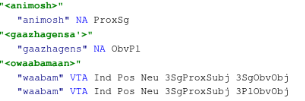

In [9]:
word_form_template = '"<{WORD_FORM}>"'

In [10]:
def fst_tags_to_cg3_reading(fst_analysis:str) -> str:
    """ Convert FST tags to CG3 reading format, e.g. 
        waabam+VTA+Cnj+Pos+Neu+1SgSubj+3SgProxObj -> "waabam" VTA Cnj Pos Neu 1SgSubj 3SgProxObj
    """
    output = ""
    tags = fst_analysis.split("+") 
    if tags[0].startswith("PV"):
        # special case, PVTense, etc tag starts BEFORE the lemma -> lemma is at position 1
        lemma = tags.pop(1) 
        
    else: 
        lemma = tags.pop(0)
    
    # post processing
    lemma = f'"{lemma}"'
    tags = " ".join(tags)    

    output = f"{lemma} {tags}"
    return output 

fst_analysis = "waabam+VTA+Cnj+Pos+Neu+1SgSubj+3SgProxObj"
reading_result = fst_tags_to_cg3_reading(fst_analysis=fst_analysis)
assert reading_result.startswith('"waabam"')
assert reading_result.endswith("3SgProxObj")
assert "+" not in reading_result 
assert len(reading_result.split()) == 7
print(reading_result)

fst_analysis = "PVTense/gii+waabam+VTA+Cnj+Pos+Neu+1SgSubj+3SgProxObj"
reading_result = fst_tags_to_cg3_reading(fst_analysis=fst_analysis)
assert reading_result.startswith('"waabam"')
assert reading_result.endswith("3SgProxObj")
assert "PVTense" in reading_result
assert "+" not in reading_result 
assert len(reading_result.split()) == 8
print(reading_result)


print("Passed")


"waabam" VTA Cnj Pos Neu 1SgSubj 3SgProxObj
"waabam" PVTense/gii VTA Cnj Pos Neu 1SgSubj 3SgProxObj
Passed


In [11]:
def fst_output_to_cg3_format(fst_item:dict[str, list]) -> str:
    """Reformat FST output to CG3 format """
    output = ""
    word_form = fst_item.get("word_form", "")
    
    word_form_line = f'"<{word_form}>"'
    reading_lines = []
    
    for analysis in fst_item.get("fst_analyses", []):
        reading_line_item = f"\t{fst_tags_to_cg3_reading(fst_analysis=analysis)}"
        reading_lines.append(reading_line_item)
    
    output = f"{word_form_line}\n{'\n'.join(reading_lines)}"
    return output
    
print(fst_output_to_cg3_format(fst_item=sentence_fst_outputs[1]))
     

"<iwidi>"
	"iwidi" ADVLoc


In [12]:
for item in sentence_fst_outputs:
    print(fst_output_to_cg3_format(fst_item=item))


"<mii>"
	"mii" ADVPred
"<iwidi>"
	"iwidi" ADVLoc
"<gii-waabamag>"
	"waabam" PVTense/gii VTA Cnj Pos Neu 1SgSubj 3SgProxObj
"<waawaashkeshi>"
	"waawaashkeshi" NA ProxSg
"<jiigaakwaa>"
	"jiigaakwaa" ADVLoc
"<.>"



In [13]:
input_readings = "\n".join([fst_output_to_cg3_format(fst_item=item)
                            for item in sentence_fst_outputs
                            ])

print(input_readings)

"<mii>"
	"mii" ADVPred
"<iwidi>"
	"iwidi" ADVLoc
"<gii-waabamag>"
	"waabam" PVTense/gii VTA Cnj Pos Neu 1SgSubj 3SgProxObj
"<waawaashkeshi>"
	"waawaashkeshi" NA ProxSg
"<jiigaakwaa>"
	"jiigaakwaa" ADVLoc
"<.>"



In [14]:
def objiwe_sentence_to_cg3_format(ojibwe_sentence:str) -> str:
    """Convert an Ojibwe sentence to cg3 input format """
    output = "" 
    tokens = tokenize(ojibwe_sentence=ojibwe_sentence)
    print("Tokens =", tokens)
    sentence_fst_outputs = fst_parse_sentence(input_words=tokens, fst_parser=fst)
    output = "\n".join([fst_output_to_cg3_format(fst_item=item)
                        for item in sentence_fst_outputs
                        ])
    return output

print(objiwe_sentence_to_cg3_format(ojibwe_sentence=ojibwe_sentence))

Tokens = ['mii', 'iwidi', 'gii-waabamag', 'waawaashkeshi', 'jiigaakwaa', '.']
"<mii>"
	"mii" ADVPred
"<iwidi>"
	"iwidi" ADVLoc
"<gii-waabamag>"
	"waabam" PVTense/gii VTA Cnj Pos Neu 1SgSubj 3SgProxObj
"<waawaashkeshi>"
	"waawaashkeshi" NA ProxSg
"<jiigaakwaa>"
	"jiigaakwaa" ADVLoc
"<.>"



In [15]:
# change to a new sentence
sentence = "animosh gaazhagensa' owaabamaan."
input_readings = objiwe_sentence_to_cg3_format(ojibwe_sentence=sentence)
print(input_readings)


Tokens = ['animosh', "gaazhagensa'", 'owaabamaan', '.']
"<animosh>"
	"animosh" NA ProxSg
"<gaazhagensa'>"
	"gaazhagens" NA ObvPl
"<owaabamaan>"
	"waabam" VTA Ind Pos Neu 3SgProxSubj 3SgObvObj
	"waabam" VTA Ind Pos Neu 3SgProxSubj 3PlObvObj
"<.>"



### Calling CG3 grammar parser

In [16]:
import subprocess

In [17]:
def is_cg3_available() -> bool: 
    """ Check if CG3 is installed in the system"""
    command = ["cg3", "--help"]  # display cg3 help
    output = subprocess.run(command, capture_output=True, text=True)
    
    return output.returncode == 0 # return code = 0 means calling cg3 successfully

is_cg3_available()

True

In [18]:
GRAMMAR_FILE = "../data/CG3_rules/Ojibwe.cg3"

In [19]:
# show grammar file
!cat {GRAMMAR_FILE}

# This is an example Constraint Grammar rules file.

# There is no built-in manual yet. Resources:
# http://visl.sdu.dk/cg3.html
# http://groups.google.com/group/constraint-grammar
# http://kevindonnelly.org.uk/2010/05/constraint-grammar-tutorial/

# Firstly, we need to define what tags should be considered sentence delimiters. For this example, only full stop is set as delimiter.
#  "<owaabamaan>"
# 	"waabam" VTA Ind Pos Neu 3SgProxSubj 3SgObvObj
#  	"waabam" VTA Ind Pos Neu 3SgProxSubj 3PlObvObj

DELIMITERS = "<.>" ;

# We can define sets for common tag clusters
LIST VTA = VTA ;
LIST 3SgObvObj = 3SgObvObj ; # 3rd Singular Obviative Object
LIST 3PlObvObj = 3PlObvObj ; # 3rd Plural Obviative Object
LIST 3SgProxSubj = 3SgProxSubj ; # 3rd Singular Proximate Subject
LIST 3PlProxSubj = 3PlProxSubj ; # 3rd Plural Proximate Subject
LIST NA = NA ;
LIST ProxSg = ProxSg ;
LIST ProxPl = ProxPl ;
LIST ObvSg = ObvSg ;
LIST ObvPl = ObvPl ;

SECTION
# If there is a Singular Proximate Noun to the lef

In [20]:
def cg3_process_text(input_text:str, cg3_grammar_filepath:str) -> str:
    """Call CG3 parser to process input text, using a custom cg3 rules file """
    command = ["cg3", "-g", cg3_grammar_filepath]  
    process = subprocess.Popen(command, 
                               stdin=subprocess.PIPE,
                               stdout=subprocess.PIPE,
                               stderr=subprocess.PIPE,
                               text=True,
                               encoding="utf-8"                        
                               )
    try:
        output, error = process.communicate(input=input_text)
        if error:
            print("Error:", error)
        return output
    except Exception as e:
        print("Error:", e)
        return "" 
 

disambiguated_str = cg3_process_text(input_text=input_readings, cg3_grammar_filepath=GRAMMAR_FILE)


In [21]:
print("Before disambiguation:")
print(input_readings)
print("-"*20)
print("After disambiguation:")
print(disambiguated_str)

Before disambiguation:
"<animosh>"
	"animosh" NA ProxSg
"<gaazhagensa'>"
	"gaazhagens" NA ObvPl
"<owaabamaan>"
	"waabam" VTA Ind Pos Neu 3SgProxSubj 3SgObvObj
	"waabam" VTA Ind Pos Neu 3SgProxSubj 3PlObvObj
"<.>"

--------------------
After disambiguation:
"<animosh>"
	"animosh" NA ProxSg
"<gaazhagensa'>"
	"gaazhagens" NA ObvPl
"<owaabamaan>"
	"waabam" VTA Ind Pos Neu 3SgProxSubj 3PlObvObj
"<.>"


